# SCF and Multipole Expansions

galpy can represent arbitrary density distributions using basis-function expansions
(SCF) and multipole expansions. This notebook demonstrates both approaches.

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import (
    SCFPotential,
    MultipoleExpansionPotential,
    DiskSCFPotential,
    NFWPotential,
)
from galpy.orbit import Orbit

## SCFPotential from a density: prolate NFW

The `SCFPotential.from_density` class method builds an SCF expansion from any
density function. Let's use it to represent a prolate (flattened along R) NFW halo.

In [2]:
# Define a prolate NFW density: stretch z by factor 1.5
nfw = NFWPotential(a=2.0, normalize=0.35)


def prolate_nfw_dens(R, z, phi=0.0):
    # Squeeze z to make it prolate
    return nfw.dens(R, z / 1.5) / 1.5


# Build SCF expansion
scf_prolate = SCFPotential.from_density(
    prolate_nfw_dens, N=10, L=6, a=2.0, symmetry="axi"
)

/home/bovy/Repos/galpy/galpy/potential/TwoPowerSphericalPotential.py:173: RuntimeWarning: divide by zero encountered in scalar divide
  (self.a / r) ** self.alpha



Compare the SCF expansion to the true density along the z-axis:

/home/bovy/Repos/galpy/galpy/potential/SCFPotential.py:534: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  out = numpy.divide((r / a - 1.0), (r / a + 1.0), where=True ^ numpy.isinf(r))



Text(0.5, 1.0, 'Prolate NFW density comparison')

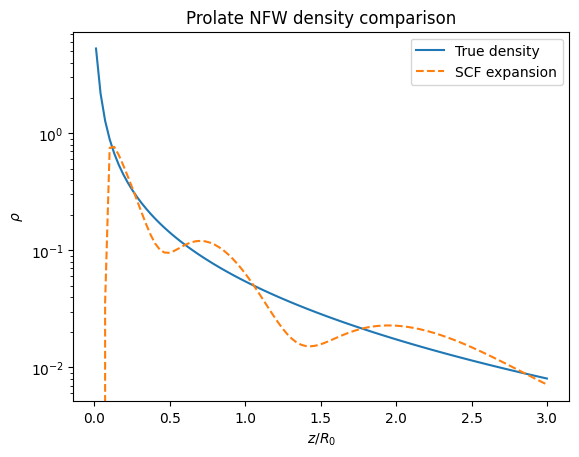

In [3]:
# Compare densities along the z-axis
zs = numpy.linspace(0.01, 3.0, 100)
dens_true = [prolate_nfw_dens(0.01, z) for z in zs]
dens_scf = [scf_prolate.dens(0.01, z) for z in zs]

plt.semilogy(zs, dens_true, label="True density")
plt.semilogy(zs, dens_scf, "--", label="SCF expansion")
plt.xlabel(r"$z / R_0$")
plt.ylabel(r"$\rho$")
plt.legend()
plt.title("Prolate NFW density comparison")

We can integrate orbits in this SCF potential just like any other galpy potential:

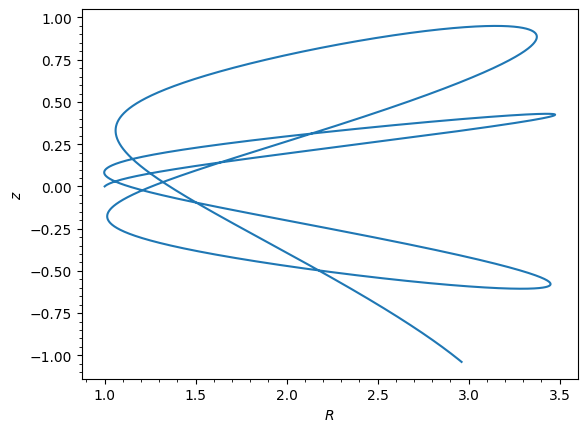

In [4]:
# Integrate an orbit in the prolate NFW SCF potential
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 50.0, 10001)
o.integrate(ts, scf_prolate)
o.plot()

## MultipoleExpansionPotential from a density

`MultipoleExpansionPotential.from_density` uses a multipole expansion to
represent the potential of an arbitrary density distribution.

In [5]:
# Build a multipole expansion of the same prolate NFW
mep = MultipoleExpansionPotential.from_density(
    prolate_nfw_dens, L=6, rgrid=numpy.geomspace(0.01, 50.0, 201), symmetry="axi"
)

Compare the SCF and multipole potentials along the midplane:

Text(0.5, 1.0, 'Potential comparison: SCF vs. Multipole')

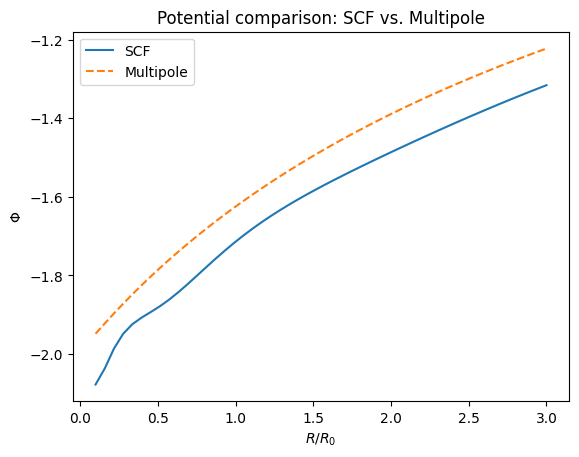

In [6]:
# Compare potentials
Rs = numpy.linspace(0.1, 3.0, 50)
pot_scf = [scf_prolate(R, 0.0) for R in Rs]
pot_mep = [mep(R, 0.0) for R in Rs]

plt.plot(Rs, pot_scf, label="SCF")
plt.plot(Rs, pot_mep, "--", label="Multipole")
plt.xlabel(r"$R / R_0$")
plt.ylabel(r"$\Phi$")
plt.legend()
plt.title("Potential comparison: SCF vs. Multipole")

## Computing SCF coefficients manually

You can also compute SCF coefficients yourself and pass them to `SCFPotential`:

In [7]:
from galpy.potential import scf_compute_coeffs_axi

# Compute coefficients for the spherical NFW
Acos, Asin = scf_compute_coeffs_axi(lambda R, z: nfw.dens(R, z), N=10, L=2, a=2.0)

# Build SCF potential from coefficients
scf_manual = SCFPotential(Acos=Acos, Asin=Asin, a=2.0)
print("Manual SCF Phi(1,0):", scf_manual(1.0, 0.0))
print("Direct NFW Phi(1,0):", nfw(1.0, 0.0))

Manual SCF Phi(1,0): -1.9650618214993711
Direct NFW Phi(1,0): -1.967410177842666


## DiskSCFPotential for disky potentials

`DiskSCFPotential` is designed for disk-like density distributions. It separates
the disk component from the spherical expansion to improve accuracy.

/home/bovy/Repos/galpy/galpy/potential/KuijkenDubinskiDiskExpansionPotential.py:363: RuntimeWarning: divide by zero encountered in scalar divide
  out -= a * (s(r) * h(z) + d2s(r) * H(z) + 2.0 / r * ds(r) * (H(z) + z * dH(z)))

/home/bovy/Repos/galpy/galpy/potential/KuijkenDubinskiDiskExpansionPotential.py:363: RuntimeWarning: invalid value encountered in scalar multiply
  out -= a * (s(r) * h(z) + d2s(r) * H(z) + 2.0 / r * ds(r) * (H(z) + z * dH(z)))



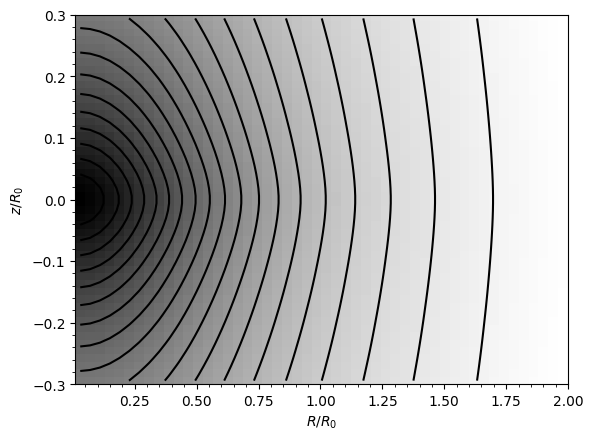

In [8]:
# Double exponential disk: Sigma(R) * h(z)
# with Sigma(R) = exp(-3R), h(z) = exp(-27|z|)
dscf = DiskSCFPotential(
    dens=lambda R, z: 13.5 * numpy.exp(-3.0 * R) * numpy.exp(-27.0 * numpy.fabs(z)),
    Sigma={"type": "exp", "h": 1.0 / 3.0, "amp": 1.0},
    hz={"type": "exp", "h": 1.0 / 27.0},
    N=10,
    L=10,
    a=1.0,
)

# Plot the potential
dscf.plot(rmin=0.01, rmax=2.0, zmin=-0.3, zmax=0.3, nrs=50, nzs=50)

## Time-dependent MultipoleExpansionPotential

The `MultipoleExpansionPotential` supports time dependence. For example,
we can represent a slowly rotating bar perturbation.

Text(0.5, 1.0, 'Time-dependent multipole expansion')

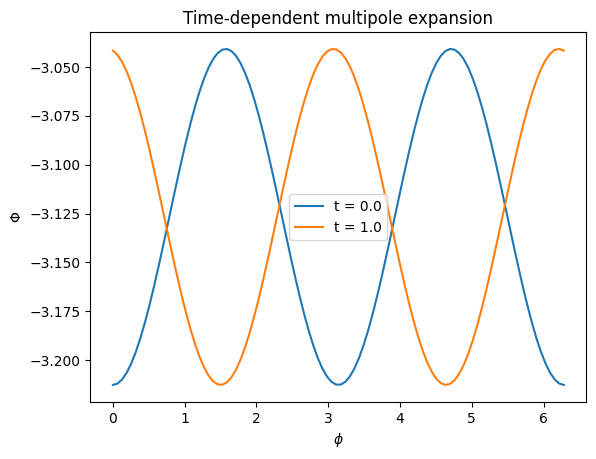

In [9]:
# Time-dependent density: a rotating triaxial perturbation
def rotating_bar_dens(R, z, phi=0.0, t=0.0):
    OmegaP = 1.5
    phi_bar = phi - OmegaP * t
    r2 = R**2 + z**2
    # Hernquist-like density with cos(2*phi) perturbation
    rho0 = 1.0 / (r2**0.5 * (1 + r2**0.5) ** 3)
    return rho0 * (1.0 + 0.3 * numpy.cos(2 * phi_bar))


mep_td = MultipoleExpansionPotential.from_density(
    rotating_bar_dens,
    L=4,
    rgrid=numpy.geomspace(0.01, 20.0, 101),
    symmetry=None,
    tgrid=numpy.linspace(0.0, 4.0 * numpy.pi / 1.5, 51),
)

# Potential at fixed R, z as function of phi at two times
phis = numpy.linspace(0, 2 * numpy.pi, 100)
for t in [0.0, 1.0]:
    vals = [mep_td(1.0, 0.0, phi=phi, t=t) for phi in phis]
    plt.plot(phis, vals, label=f"t = {t:.1f}")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\Phi$")
plt.legend()
plt.title("Time-dependent multipole expansion")

## SCFPotential with TriaxialNFWPotential (from the docs)

The following examples are adapted from the galpy documentation. We use a
`TriaxialNFWPotential` with `c=1.4` (prolate) as the target density and
fit it with both SCF and multipole expansions.

In [10]:
from galpy.potential import TriaxialNFWPotential

np_tri = TriaxialNFWPotential(normalize=1.0, c=1.4, a=1.0)

# SCF expansion with a large scale parameter (works well for NFW)
a_SCF = 50.0
sp_tri = SCFPotential.from_density(
    np_tri.dens, 80, L=40, a=a_SCF, symmetry="axisymmetry"
)

/home/bovy/Repos/galpy/galpy/potential/TwoPowerTriaxialPotential.py:551: RuntimeWarning: divide by zero encountered in scalar divide
  return self.a / m / (1.0 + m / self.a) ** 2



Compare the densities along the `R=Z` line:

Text(0.5, 1.0, 'TriaxialNFW: SCF density comparison along R=z')

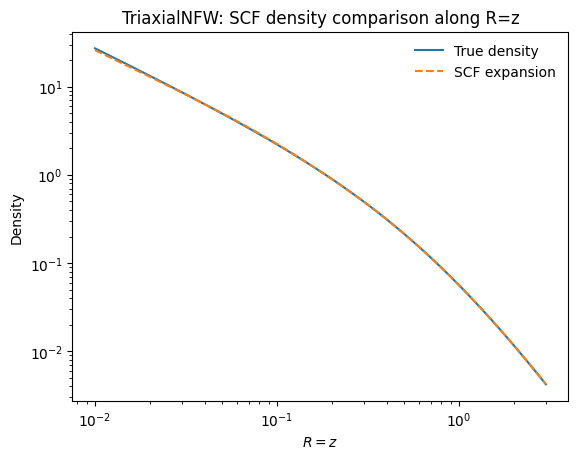

In [11]:
xs = numpy.linspace(0.01, 3.0, 1001)
plt.loglog(xs, [np_tri.dens(x, x) for x in xs], label="True density")
plt.loglog(xs, sp_tri.dens(xs, xs), "--", label="SCF expansion")
plt.xlabel(r"$R = z$")
plt.ylabel(r"Density")
plt.legend(frameon=False)
plt.title("TriaxialNFW: SCF density comparison along R=z")

Integrate an orbit in both the true and SCF potentials to compare:

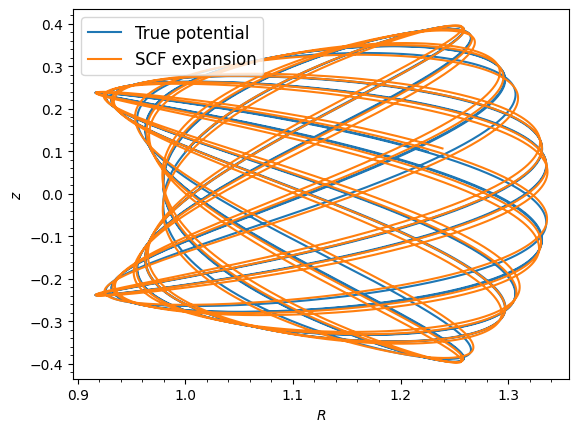

In [12]:
o_true = Orbit([1.0, 0.1, 1.1, 0.1, 0.3, 0.0])
ts = numpy.linspace(0.0, 100.0, 10001)
o_true.integrate(ts, np_tri)
o_true.plot(label="True potential")

o_scf = Orbit([1.0, 0.1, 1.1, 0.1, 0.3, 0.0])
o_scf.integrate(ts, sp_tri)
o_scf.plot(overplot=True, label="SCF expansion")
plt.legend(fontsize=12.0)

## MultipoleExpansionPotential with TriaxialNFWPotential

We can also use a multipole expansion for the same density:

In [13]:
mep_tri = MultipoleExpansionPotential.from_density(
    lambda R, z, phi: np_tri.dens(R, z, phi), L=40, symmetry="axisymmetry"
)

Compare the SCF, multipole, and true densities along the `R=Z` line:

Text(0, 0.5, 'Density$(R,z)$')

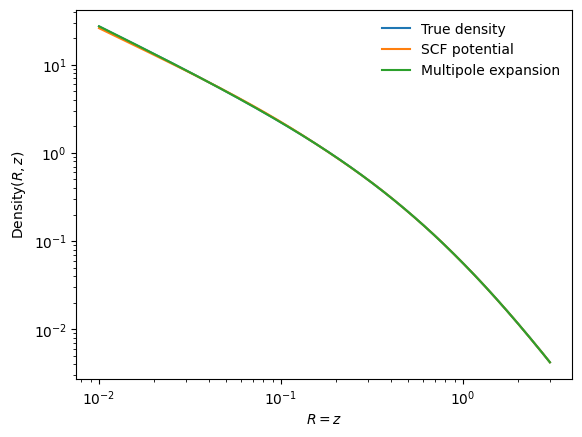

In [14]:
xs = numpy.linspace(0.01, 3.0, 1001)
plt.loglog(xs, [np_tri.dens(x, x) for x in xs], "-", label="True density")
plt.loglog(xs, sp_tri.dens(xs, xs), "-", label="SCF potential")
plt.loglog(xs, mep_tri.dens(xs, xs), "-", label="Multipole expansion")
plt.legend(frameon=False, loc="upper right")
plt.xlabel(r"$R = z$")
plt.ylabel(r"Density$(R,z)$")

Orbit integration with the multipole expansion also gives good agreement:

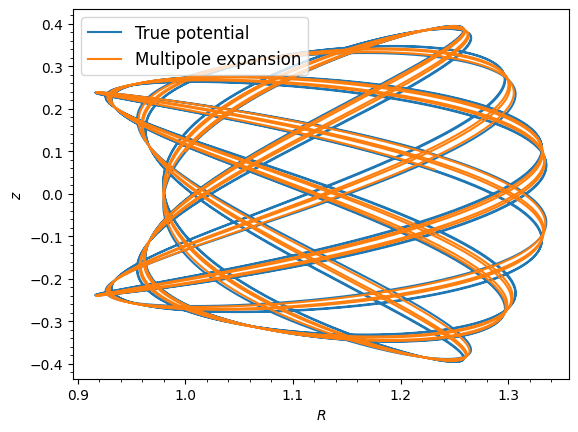

In [15]:
o_true2 = Orbit([1.0, 0.1, 1.1, 0.1, 0.3, 0.0])
ts = numpy.linspace(0.0, 100.0, 10001)
o_true2.integrate(ts, np_tri)
o_true2.plot(label="True potential")

o_mep = Orbit([1.0, 0.1, 1.1, 0.1, 0.3, 0.0])
o_mep.integrate(ts, mep_tri)
o_mep.plot(overplot=True, label="Multipole expansion")
plt.legend(fontsize=12.0)

## DiskSCFPotential with DoubleExponentialDiskPotential (from the docs)

`DiskSCFPotential` uses a trick from Kuijken & Dubinski (1995) to handle
disk-like densities. We compare it to the `DoubleExponentialDiskPotential`:

In [16]:
from galpy.potential import DoubleExponentialDiskPotential

dp = DoubleExponentialDiskPotential(amp=13.5, hr=1.0 / 3.0, hz=1.0 / 27.0)

dscfp = DiskSCFPotential(
    dens=lambda R, z: dp.dens(R, z),
    Sigma={"type": "exp", "h": 1.0 / 3.0, "amp": 1.0},
    hz={"type": "exp", "h": 1.0 / 27.0},
    a=1.0,
    N=10,
    L=10,
)

/home/bovy/Repos/galpy/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/home/bovy/Repos/galpy/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/home/bovy/Repos/galpy/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (



Compare the density along the `R = 10z` line:

Text(0.5, 1.0, 'Density along R = 10z')

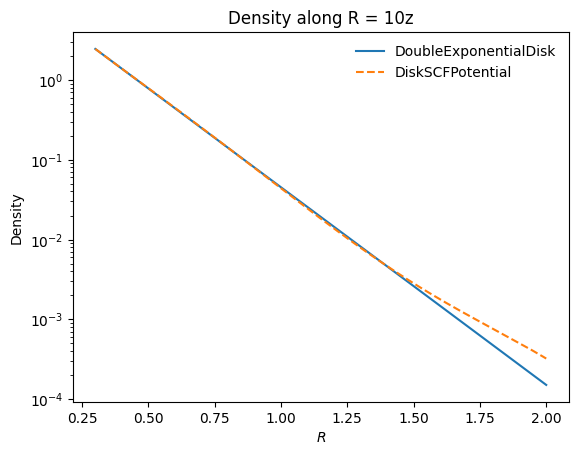

In [17]:
xs = numpy.linspace(0.3, 2.0, 1001)
plt.semilogy(xs, dp.dens(xs, xs / 10.0), label="DoubleExponentialDisk")
plt.semilogy(xs, dscfp.dens(xs, xs / 10.0), "--", label="DiskSCFPotential")
plt.xlabel(r"$R$")
plt.ylabel(r"Density")
plt.legend(frameon=False)
plt.title("Density along R = 10z")

Integrate and compare orbits. Note that `DiskSCFPotential` is much faster
than `DoubleExponentialDiskPotential` for orbit integration:

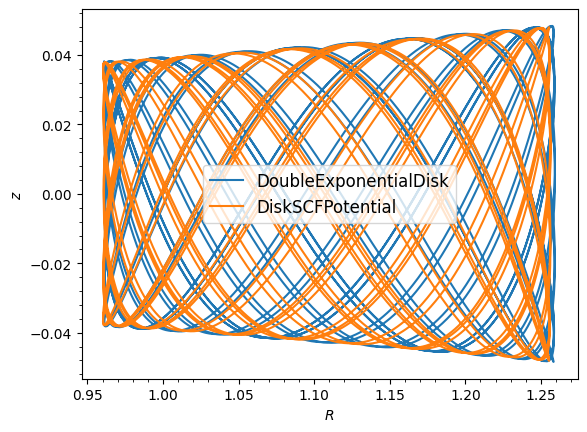

In [18]:
o_dp = Orbit([1.0, 0.1, 0.9, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 100.0, 10001)
o_dp.integrate(ts, dp)
o_dp.plot(label="DoubleExponentialDisk")

o_dscf = Orbit([1.0, 0.1, 0.9, 0.0, 0.1, 0.0])
o_dscf.integrate(ts, dscfp)
o_dscf.plot(overplot=True, label="DiskSCFPotential")
plt.legend(fontsize=12.0)

## Hernquist coefficient example (from the docs)

The Hernquist potential is the lowest-order SCF basis function, so only the
zeroth-order coefficient should be non-zero when computing the SCF expansion:

In [19]:
from galpy.potential import HernquistPotential, scf_compute_coeffs_spherical

hp = HernquistPotential(amp=1.0, a=2.0)
Acos, Asin = scf_compute_coeffs_spherical(hp.dens, 10, a=2.0)

# Only the lowest-order coefficient should be non-zero (= 1)
print("Acos coefficients:")
print(Acos)
print(
    "\nNote: only Acos[0,0,0] = 1.0 is non-zero; all others are ~0 (machine precision)."
)

/home/bovy/Repos/galpy/galpy/potential/TwoPowerSphericalPotential.py:419: RuntimeWarning: divide by zero encountered in scalar divide
  (self.a / r) ** self.alpha

Acos coefficients:
[[[ 1.00000000e+00]]

 [[ 8.65722568e-18]]

 [[-1.13278379e-16]]

 [[-2.93522527e-18]]

 [[-3.04900866e-17]]

 [[-8.03257697e-20]]

 [[-1.36005913e-17]]

 [[ 1.30909657e-18]]

 [[-5.31153122e-18]]

 [[-6.69176217e-19]]]

Note: only Acos[0,0,0] = 1.0 is non-zero; all others are ~0 (machine precision).


To initialize an `SCFPotential` from these coefficients:
```python
sp_hernquist = SCFPotential(Acos=Acos, Asin=Asin, a=2.)
```